In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pmt.io import (
    find_pmt_files,
    read_waveform_sample,
)
from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [2]:
file_name = "WA0089_850V_20MHz_Cold_led1"
# file_name = "WA0089_850V_20MHz_Cold_led2"
# file_name = "WA0089_850V_20MHz_Cold_led3"
# file_name = "WA0089_850V_20MHz_Cold_led4"
# file_name = "WA0089_850V_20MHz_Cold_led5"
# file_name = "WA0089_850V_20MHz_Cold_led6"
# file_name = "WA0089_850V_20MHz_Cold_led7"
# file_name = "WA0089_850V_20MHz_Cold_led8"
# file_name = "WA0089_850V_20MHz_Cold_led9"
data_dir = Path("data/WA0089/LED_sweep/260615")

# Set to a number for quick iteration, or None to use all matching files.
max_files = 1

files = find_pmt_files(data_dir, file_name, max_files=max_files)

for file in files:
    print(file)
print(f"Number of files loaded: {len(files)}")


data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-1.h5
Number of files loaded: 1


### if and where to save plots

In [3]:
save_plots = False
save_dir = 'plots_selection'
file_nickname = file_name

# Configuration

In [4]:
cfg = load_config("config_default.yml", file_name)
print(cfg)

[general]
baseline_window_width_ns = 20
integration_window_ns = (30, 80)
peak_search_window_ns = (30, 80)
global_peak_voltage_max_mV = None
out_of_window_peak_voltage_max_mV = -1.0
allowed_peak_window_ns = (30, 40)

[fit_general]
fit_range = (-15.0, 80.0)
fit_nbins = 250



In [5]:
rise_low_fraction = 0.1
rise_high_fraction = 0.9
# show_residual_errorbars = True # I always want it...
chunk_size = 512 #4096

baseline_window_width_ns          = cfg.general.baseline_window_width_ns
integration_window_ns             = cfg.general.integration_window_ns

# refactor: make this one variable
peak_search_window_ns             = cfg.general.peak_search_window_ns  
allowed_peak_window_ns            = cfg.general.allowed_peak_window_ns
# peak_time_window_mV = 
out_of_window_peak_voltage_max_mV = cfg.general.out_of_window_peak_voltage_max_mV
# peak_finding_threshold_mV = 

selection_peak_threshold_max_mV        = cfg.general.global_peak_voltage_max_mV
# baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + config["baseline_window_width_ns"]))



# 1. Partial Sample


In [6]:
max_sample_events = None

sample = read_waveform_sample(files, max_events=max_sample_events)

time_ns = sample["time_ns"]
voltage_sample_mV = sample["voltage_mV"]
adc_step_mV = sample["adc_step_mV"]

print(f"Sample waveforms: {voltage_sample_mV.shape}")
print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV\n")
print(sample.keys())


Sample waveforms: (31682, 1601)
Time range: -0.029 to 99.971 ns
Sampling step: 0.06250 ns
ADC step: 0.000214 mV

dict_keys(['time_ns', 'voltage_mV', 'metadata', 'sample_segments', 'adc_step_mV', 'units_time', 'units_voltage'])


In [7]:
baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + baseline_window_width_ns))

In [8]:
event_info = {} # store all event-related information

## Saturated waveforms

In [9]:
# remove_saturated_waveforms( voltage_mV, metadata, low_limit_mV=None, high_limit_mV=None, margin_mV: float = 0.0, max_saturated_samples: int = 0)
kept_voltage_mV, keep_mask,  sat_evt_info, sat_summary = remove_saturated_waveforms( voltage_sample_mV, sample['metadata'][0])
print(f"efficiency = {sat_summary['efficiency']*100:.3f} %")

# keep_mask = ~sat_evt_info['is_saturated']
sat_evt_info_selected = { key: values[keep_mask] for key, values in sat_evt_info.items() }
event_info.update(sat_evt_info_selected)
event_info.keys()

efficiency = 99.984 %


dict_keys(['is_saturated', 'n_saturated_samples'])

## Baseline Subtraction


In [10]:
voltage_sample_bs_mV, baseline_evt_info = subtract_baseline(
    time_ns,
    kept_voltage_mV,
    baseline_window_ns=baseline_window_ns,
)

print(f"Baseline-subtracted sample: {voltage_sample_bs_mV.shape}")
print(f"Sample baselines: {baseline_evt_info['baseline_mean_mV'].shape}")
event_info.update(baseline_evt_info)
baseline_evt_info.keys()

Baseline-subtracted sample: (31677, 1601)
Sample baselines: (31677,)


dict_keys(['baseline_mean_mV', 'baseline_rms_mV', 'baseline_slope_mV_per_ns'])

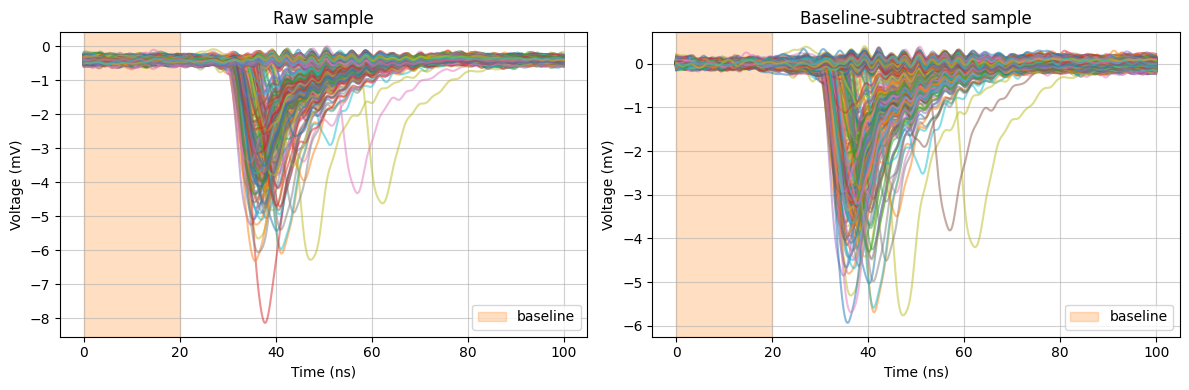

In [11]:
n_to_plot = 5000

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

add_plot_waveforms(axes[0], time_ns, voltage_sample_mV[:n_to_plot], title="Raw sample")
axes[0].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[0].legend(loc="lower right")

add_plot_waveforms(axes[1], time_ns, voltage_sample_bs_mV[:n_to_plot], title="Baseline-subtracted sample")
axes[1].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[1].legend(loc="lower right")

fig.tight_layout()
save_plot(fig, save_plots, save_dir, file_nickname,"wfs_raw_vs_bs", Nevents=n_to_plot);


[]

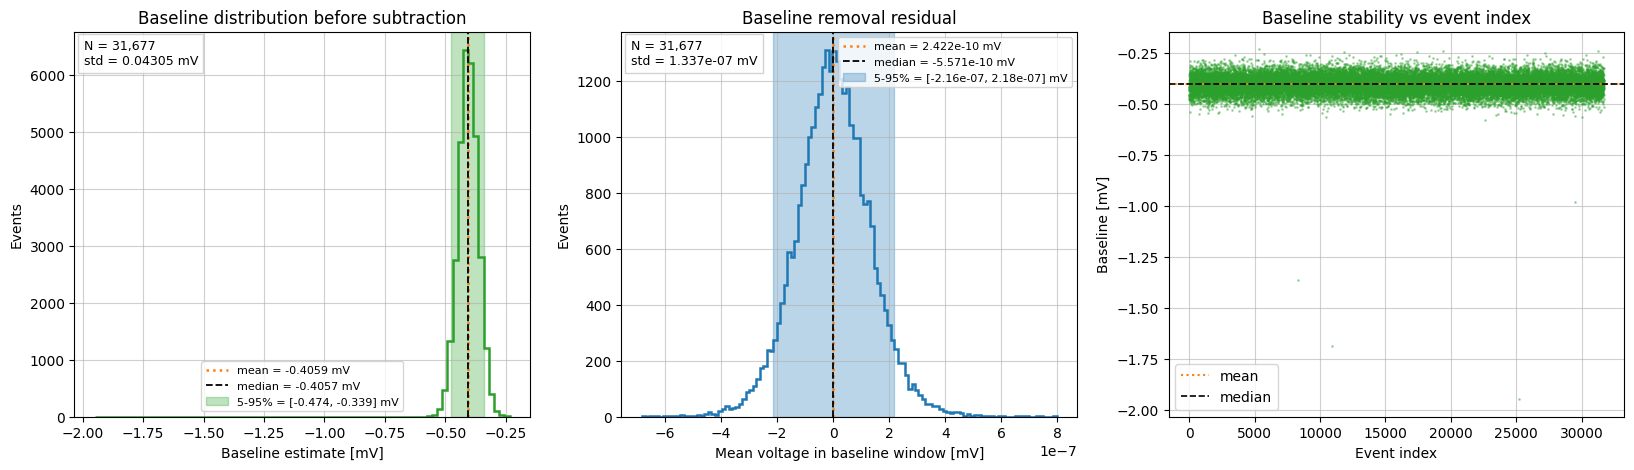

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_baseline_quality(axes, time_ns, baseline_evt_info['baseline_mean_mV'], voltage_sample_bs_mV, baseline_window_ns)

save_plot(fig, save_plots, save_dir, file_nickname, f"basline_quality",  Nevents=max_sample_events)

## Selection

In [13]:
df =  build_waveform_feature_dataframe( time_ns, voltage_sample_bs_mV, extra=event_info)
df

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:289: PeakPropertyWarning: some peaks have a prominence of 0
  widths, width_heights, left_ips, right_ips = peak_widths(
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:289: PeakPropertyWarning: some peaks have a width of 0
  widths, width_heights, left_ips, right_ips = peak_widths(


,peak_time_ns,peak_idx,peak_amplitude_mV,fwhm_ns,peak_width_ns,rise_time_10_90_ns,fall_time_90_10_ns,cfd10_rise_ns,cfd20_rise_ns,cfd30_rise_ns,...,second_peak_time_ns,second_peak_amplitude_mV,peak_separation_ns,event_id,is_saturated,n_saturated_samples,baseline_mean_mV,baseline_rms_mV,baseline_slope_mV_per_ns,snr
0,48.845558,782,0.154285,70.5000,1.560707,42.199936,0.532167,6.403391,8.529607,28.253227,...,60.220558,0.127557,11.3750,0,False,0,-0.417220,0.022482,-0.001616,6.862767
1,92.033058,1473,0.188668,42.9375,1.841263,91.338666,NaN,-0.029442,0.408747,48.570819,...,92.158058,0.188455,0.1250,1,False,0,-0.354397,0.022482,0.003139,8.391818
2,57.345558,918,0.120700,20.3125,1.777083,48.114023,0.595385,9.020463,9.512989,12.433462,...,48.845558,0.086273,-8.5000,2,False,0,-0.399058,0.027165,-0.002721,4.443184
3,28.658058,459,0.157816,51.5000,2.813405,25.345301,1.105517,2.930137,6.146373,10.582932,...,19.470558,0.133653,-9.1875,3,False,0,-0.439135,0.064233,-0.001729,2.456924
4,48.845558,782,0.105275,36.3750,1.553911,39.622366,0.457092,9.044412,9.238402,9.487635,...,60.283058,0.086672,11.4375,4,False,0,-0.459601,0.036709,-0.005404,2.867848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31672,49.158058,787,0.217527,37.8125,1.651496,39.613674,0.731169,9.269202,22.715602,23.150444,...,60.283058,0.166635,11.1250,31672,False,0,-0.385412,0.020334,-0.002280,10.697632
31673,33.033058,529,0.173565,48.3750,8.305761,16.145554,2.543903,16.337645,16.789123,17.181922,...,32.908058,0.173137,-0.1250,31673,False,0,-0.408205,0.034971,-0.005231,4.963083
31674,49.033058,785,0.175635,49.0000,1.583266,36.239575,0.684360,12.554337,12.979968,16.253064,...,65.908058,0.161309,16.8750,31674,False,0,-0.358022,0.027580,-0.002939,6.368099
31675,49.220558,788,0.175177,70.8125,1.600865,48.965411,0.734326,-0.029442,0.214587,2.997026,...,40.970558,0.150800,-8.2500,31675,False,0,-0.389272,0.029175,0.003554,6.004357


In [14]:
# reject events with main peak inside the baseline window -> the baseline computation fails when the peak in inside
# optional: require the peak to be larger than a specific  value (e.g. 0.5mV) so that we don't thouw away pedestal events
sanity_mask_reject = ( df.peak_time_ns.between( baseline_window_ns[0], baseline_window_ns[1] ) & (df.peak_amplitude_mV >= 0.5) )
sanity_mask_keep = ~sanity_mask_reject

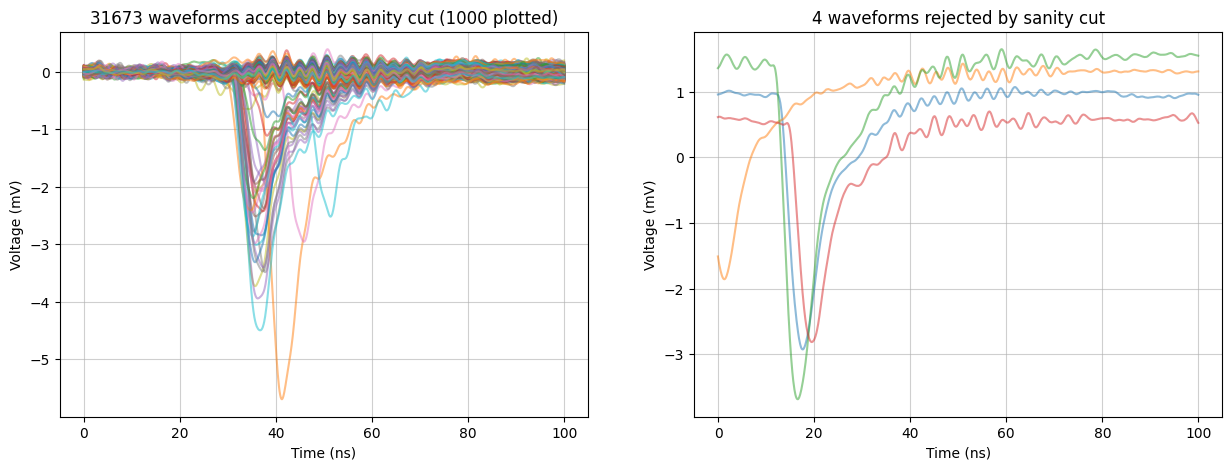

In [15]:
nEvts_plot = 1000
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.ravel()
rejected_waveforms = voltage_sample_bs_mV[sanity_mask_reject.values]
selected_waveforms = voltage_sample_bs_mV[sanity_mask_keep.values]

add_plot_waveforms(axes[0], time_ns, selected_waveforms[:nEvts_plot], title=f"{len(selected_waveforms)} waveforms accepted by sanity cut ({nEvts_plot} plotted)")
add_plot_waveforms(axes[1], time_ns, rejected_waveforms, title=f"{len(rejected_waveforms)} waveforms rejected by sanity cut")

## Selection: exploration

### 

In [16]:
df_sel = df[sanity_mask_keep].copy()
waveforms_sel = voltage_sample_bs_mV[df_sel["event_id"].values]

In [17]:
def plot_snr_distribution(ax, df_sel):

    ax.hist( df_sel["snr"], bins=100, log=True )

    ax.set_xlabel("SNR")
    ax.set_ylabel("Events")
    ax.set_title("SNR distribution");

def plot_mean_waveforms_vs_snr( ax,  df_sel, waveforms_sel, time_ns, cuts=(2, 5, 8, 10, 15, 20)):

    for cut in cuts:

        mask = df_sel["snr"] > cut
        if mask.sum() < 10:
            continue

        mean_waveform = np.mean(
            waveforms_sel[mask.values],
            axis=0,
        )

        ax.plot(
            time_ns,
            mean_waveform,
            label=f"SNR>{cut}",
        )

    ax.legend()
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Voltage (mV)")
    ax.set_title("Mean waveform vs SNR cut")

def plot_charge_histograms_vs_snr( ax,  df_sel, cuts=(2, 5, 8, 10, 15) ):

    for cut in cuts:

        mask = df_sel["snr"] > cut

        ax.hist(
            df_sel.loc[ mask, "area_mV_ns" ],
            bins=200,
            histtype="step",
            density=True,
            label=f"SNR>{cut}",
        )

    ax.legend()
    ax.set_xlabel("Charge (mV ns)")
    ax.set_ylabel("Density")
    ax.set_title("Charge distribution vs SNR cut")

def plot_snr_efficiency( ax,  df_sel, cuts=np.arange(1, 25) ):

    efficiency = []

    for cut in cuts:
        efficiency.append( np.mean( df_sel["snr"] > cut ) )

    ax.plot( cuts, efficiency, marker="o" )

    ax.set_xlabel("SNR cut")
    ax.set_ylabel("Fraction kept")
    ax.set_title("Efficiency vs SNR cut")
    ax.grid()

def plot_waveforms_in_snr_range( ax, df_sel, waveforms_sel, time_ns, snr_min=7, snr_max=9, n_waveforms=50 ):

    mask = (
        (df_sel["snr"] > snr_min)
        &
        (df_sel["snr"] < snr_max)
    )

    for waveform in waveforms_sel[
        mask.values
    ][:n_waveforms]:

        ax.plot(
            time_ns,
            waveform,
            alpha=0.7,
        )

    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Voltage (mV)")
    ax.set_title(f"{snr_min} < SNR < {snr_max}" )

def plot_snr_vs_amplitude(ax, df_sel):

    ax.scatter( df_sel["peak_amplitude_mV"], df_sel["snr"], s=1, alpha=0.7 )
    ax.set_xlabel("Peak amplitude (mV)")
    ax.set_ylabel("SNR")



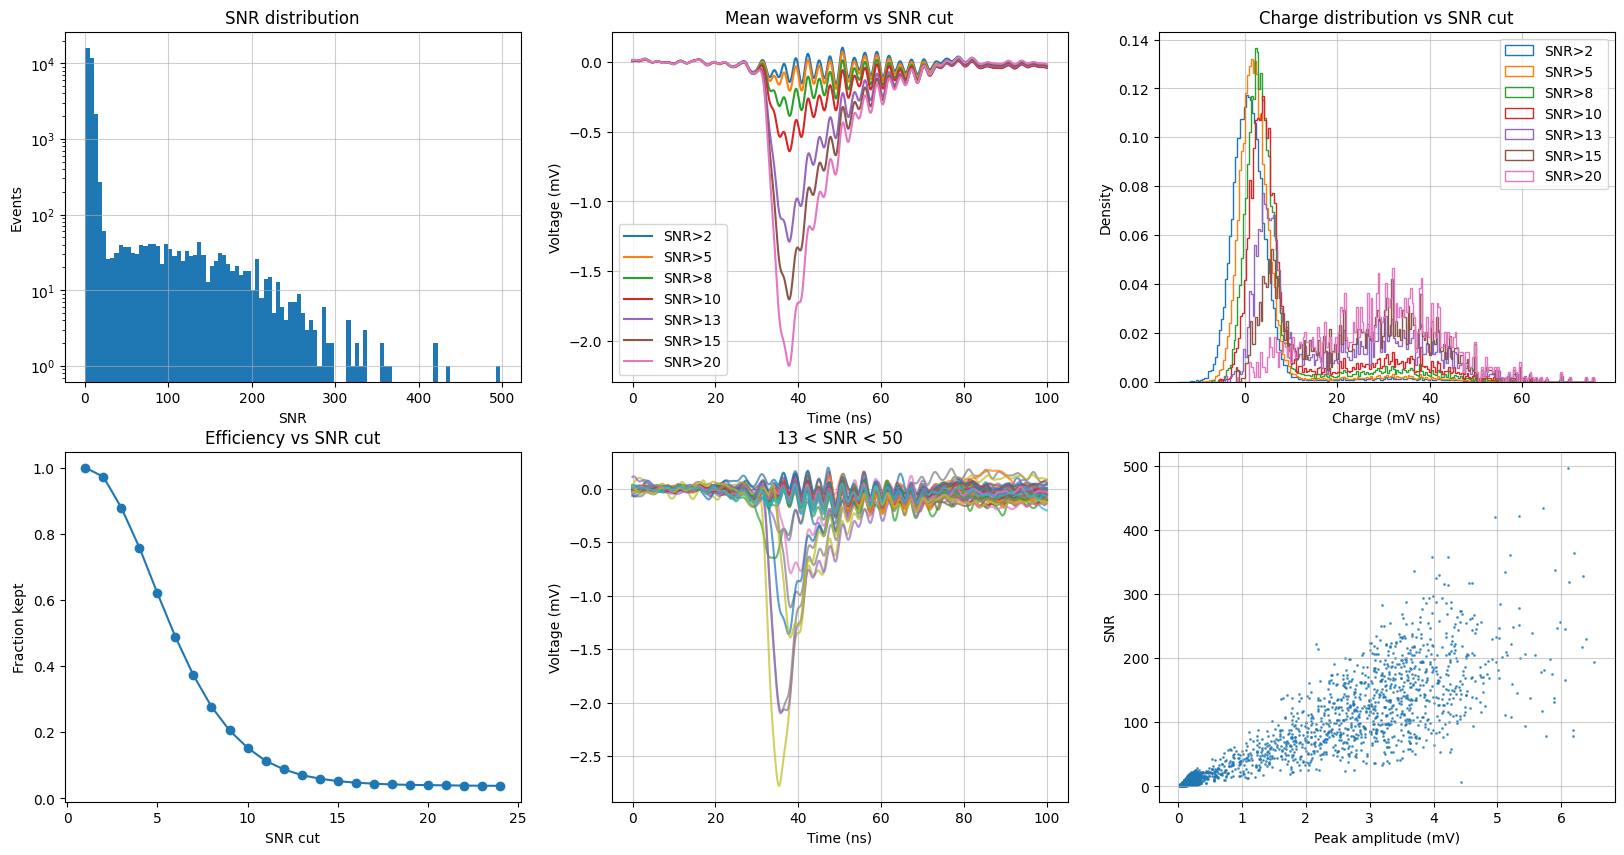

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()
plot_snr_distribution(axes[0], df_sel)
plot_mean_waveforms_vs_snr(axes[1], df_sel, waveforms_sel, time_ns, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_charge_histograms_vs_snr(axes[2], df_sel, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_snr_efficiency(axes[3], df_sel, cuts=np.arange(1, 25))
plot_waveforms_in_snr_range( axes[4],  df_sel, waveforms_sel, time_ns, snr_min=13, snr_max=50, n_waveforms=50)  
plot_snr_vs_amplitude(axes[5], df_sel)  

### improve charge computation

In [19]:
df_sel.columns

Index(['peak_time_ns', 'peak_idx', 'peak_amplitude_mV', 'fwhm_ns',
       'peak_width_ns', 'rise_time_10_90_ns', 'fall_time_90_10_ns',
       'cfd10_rise_ns', 'cfd20_rise_ns', 'cfd30_rise_ns', 'cfd50_rise_ns',
       'cfd90_rise_ns', 'cfd10_fall_ns', 'cfd20_fall_ns', 'cfd30_fall_ns',
       'cfd50_fall_ns', 'cfd90_fall_ns', 'area_mV_ns',
       'charge_peak_window_mV_ns', 'charge_cfd10_window_mV_ns',
       'charge_cfd20_window_mV_ns', 'charge_cfd30_window_mV_ns',
       'charge_cfd50_window_mV_ns', 'n_peaks', 'second_peak_time_ns',
       'second_peak_amplitude_mV', 'peak_separation_ns', 'event_id',
       'is_saturated', 'n_saturated_samples', 'baseline_mean_mV',
       'baseline_rms_mV', 'baseline_slope_mV_per_ns', 'snr'],
      dtype='str')

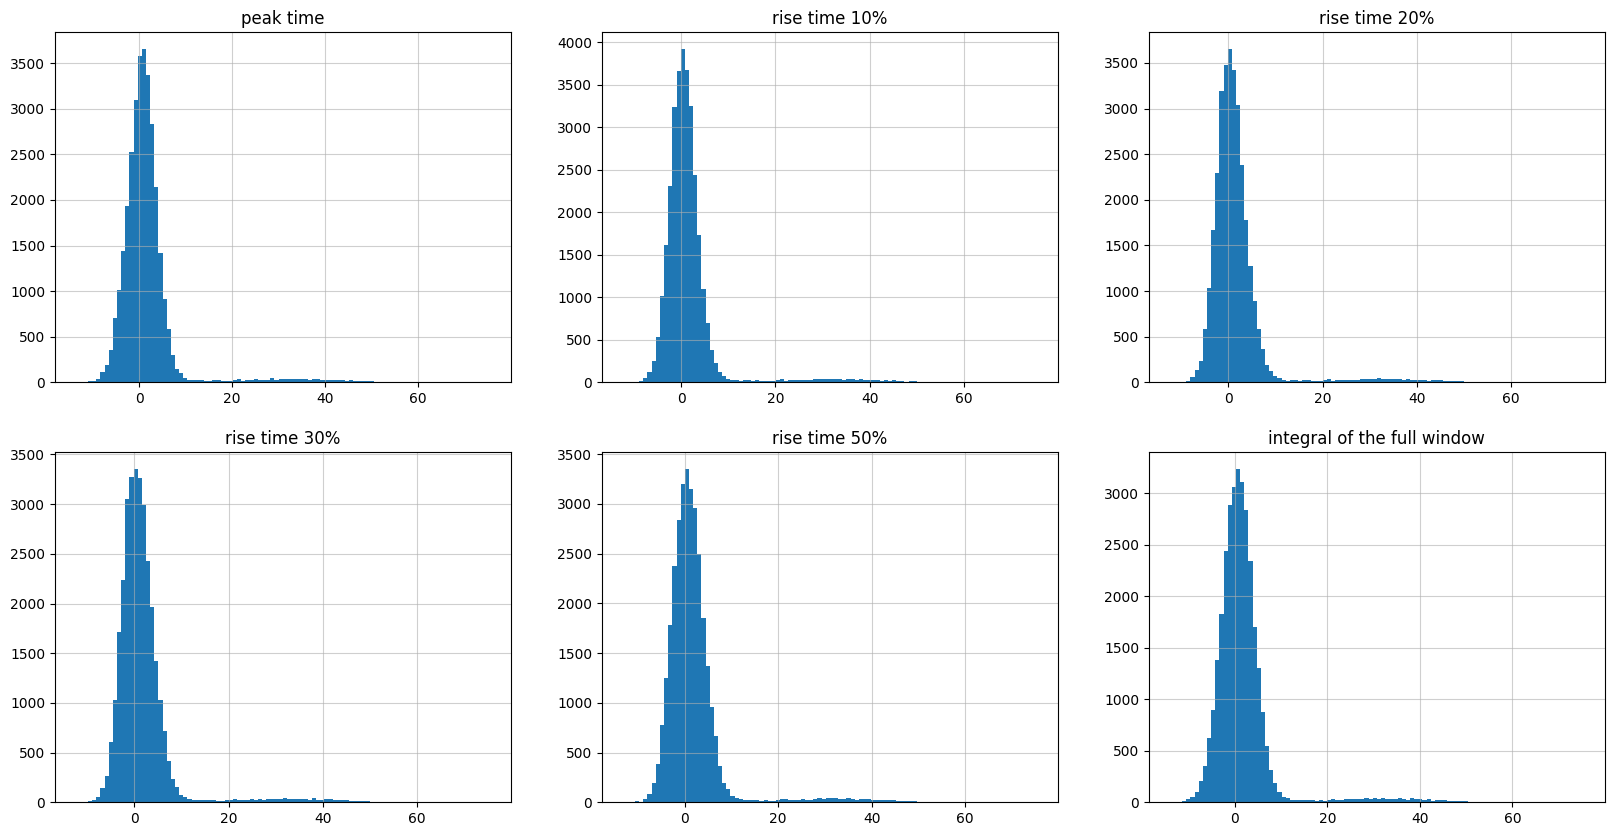

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

rg = None #(-20, 10)

axes[0].hist(df_sel.charge_peak_window_mV_ns, bins=100, range=rg);
axes[0].set_title("peak time")
axes[1].hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg);
axes[1].set_title("rise time 10%");
axes[2].hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg);
axes[2].set_title("rise time 20%");
axes[3].hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg);
axes[3].set_title("rise time 30%");
axes[4].hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg);
axes[4].set_title("rise time 50%");
axes[5].hist(df_sel.area_mV_ns, bins=100, range=rg);
axes[5].set_title("integral of the full window");


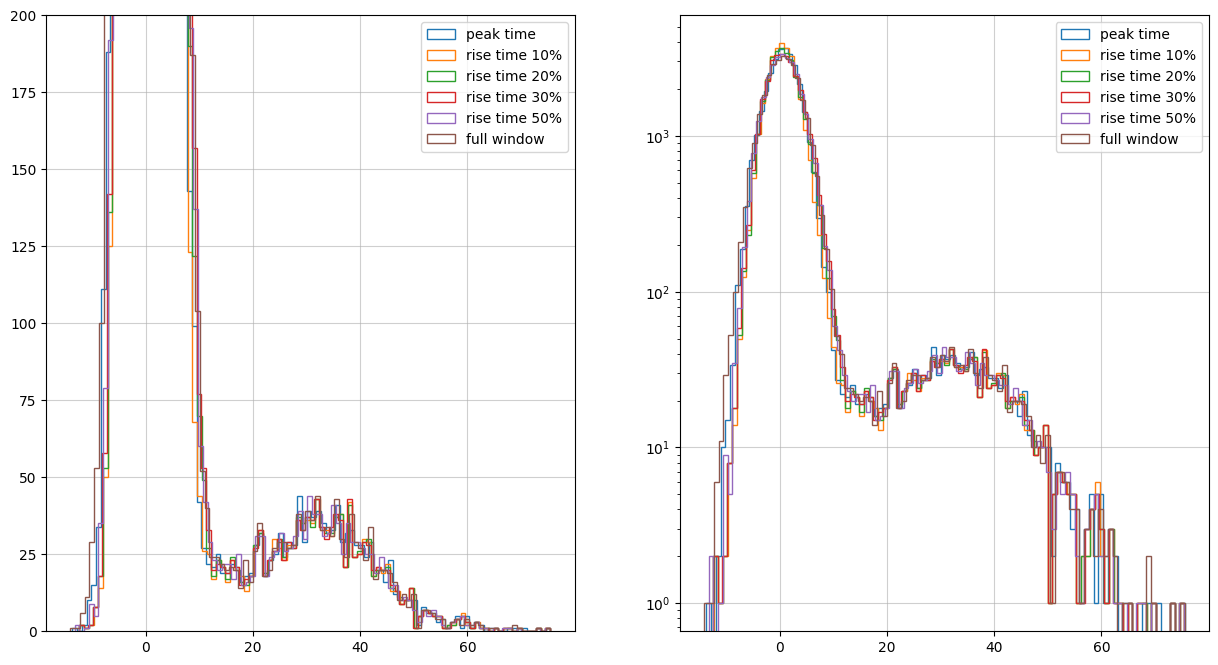

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))


rg = None #(-20, 10)
den=False

axes[0].hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes[0].hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes[0].hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes[0].hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes[0].hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes[0].hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes[0].set_ylim(0, 200)
axes[0].legend();

axes[1].hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes[1].hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes[1].hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes[1].hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes[1].hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes[1].hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes[1].set_yscale('log');
axes[1].legend();


